In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("/content/seasonal_agriculture_performance_dataset.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 4000
Columns: 28


In [3]:
print("Column names:")
print(df.columns.tolist())

Column names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [4]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [6]:
print("Missing values in each column:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values in each column:
Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3    

In [7]:
# Create a copy of the original dataset
clean_df = df.copy()

# Fill missing numerical values with their median
columns_to_fill = [
    "Rainfall_mm",
    "Soil_Moisture_pct",
    "Yield_Tonnes_Ha"
]

for column in columns_to_fill:
    clean_df[column] = clean_df[column].fillna(clean_df[column].median())

print("Missing values after cleaning:")
print(clean_df.isnull().sum().sum())

Missing values after cleaning:
0


In [8]:
clean_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,4000.0,600.922825,287.193381,80.000,371.575,582.0000,831.97500,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,4000.0,26.507150,6.678837,8.000,21.800,26.4000,31.20000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [9]:
print("Seasons:")
print(clean_df["Season"].value_counts())

print("\nCrops:")
print(clean_df["Crop"].value_counts())

print("\nIrrigation Methods:")
print(clean_df["Irrigation_Method"].value_counts())

Seasons:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Crops:
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Irrigation Methods:
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


In [10]:
season_yield = clean_df.groupby("Season")["Yield_Tonnes_Ha"].agg(
    ["count", "mean", "median", "min", "max"]
)

season_yield

,count,mean,median,min,max
Season,,,,,
Kharif,1779,5.628612,1.94,0.3,101.44
Rabi,1627,5.039435,1.67,0.3,93.13
Zaid,594,4.641313,1.46,0.3,64.76


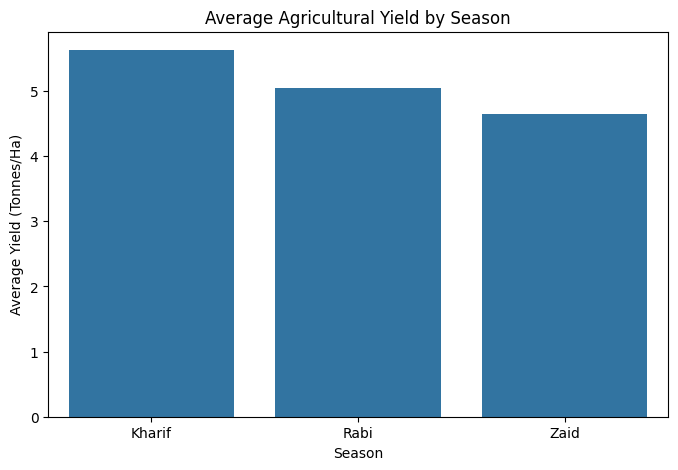

In [11]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=season_yield.reset_index(),
    x="Season",
    y="mean"
)

plt.title("Average Agricultural Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.show()

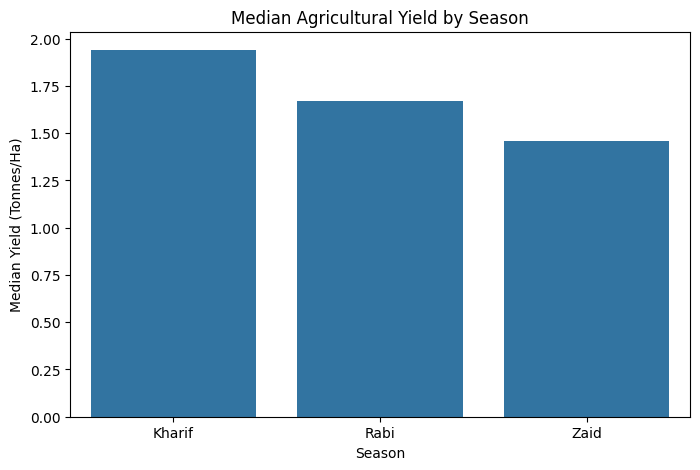

In [12]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=season_yield.reset_index(),
    x="Season",
    y="median"
)

plt.title("Median Agricultural Yield by Season")
plt.xlabel("Season")
plt.ylabel("Median Yield (Tonnes/Ha)")
plt.show()

In [13]:
season_profit = clean_df.groupby("Season")["Profit_INR"].agg(
    ["count", "mean", "median", "min", "max"]
)

season_profit

,count,mean,median,min,max
Season,,,,,
Kharif,1779,178914.647555,38808.0,-976860,4345421
Rabi,1627,87689.470191,-3187.0,-1019223,3378879
Zaid,594,-24804.824916,-62144.0,-965197,2349990


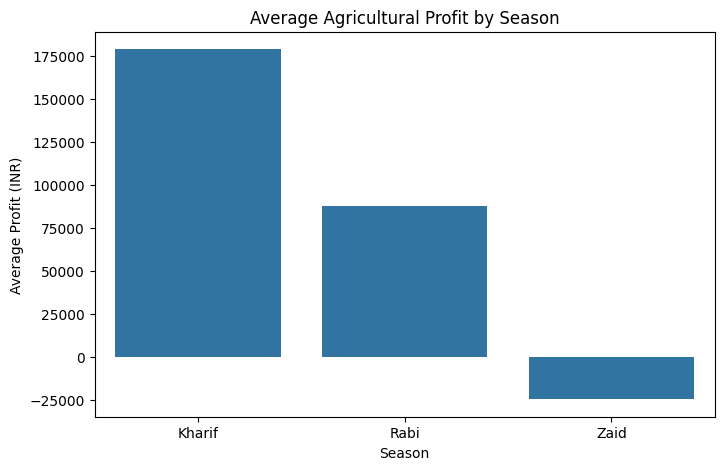

In [14]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=season_profit.reset_index(),
    x="Season",
    y="mean"
)

plt.title("Average Agricultural Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.show()

In [15]:
irrigation_profit = clean_df.groupby("Irrigation_Method")["Profit_INR"].agg(
    ["count", "mean", "median"]
)

irrigation_profit

,count,mean,median
Irrigation_Method,,,
Drip,915,219625.997814,52895.0
Flood,1310,73354.022901,-12131.0
Rainfed,1041,79050.365034,-9650.0
Sprinkler,734,91121.079019,7840.0


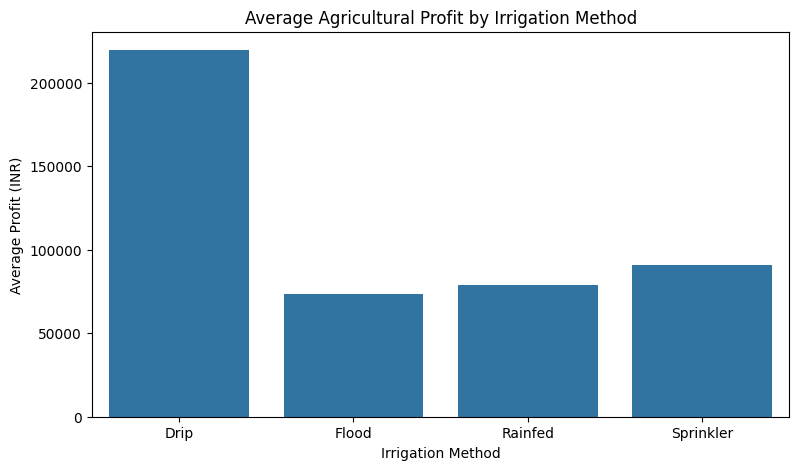

In [16]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=irrigation_profit.reset_index(),
    x="Irrigation_Method",
    y="mean"
)

plt.title("Average Agricultural Profit by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Profit (INR)")
plt.show()

In [17]:
irrigation_water = clean_df.groupby("Irrigation_Method")["Water_Efficiency_t_per_1000m3"].agg(
    ["count", "mean", "median"]
)

irrigation_water

,count,mean,median
Irrigation_Method,,,
Drip,915,6.267129,3.2580
Flood,1310,3.438853,1.9505
Rainfed,1041,7.563784,4.5810
Sprinkler,734,4.669805,2.6520


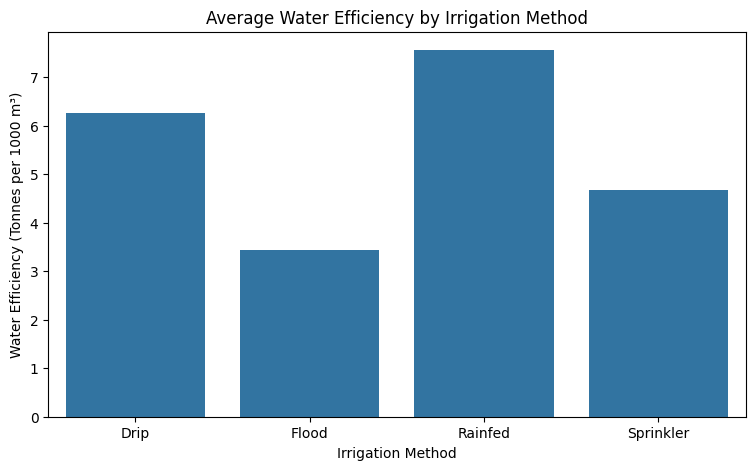

In [18]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=irrigation_water.reset_index(),
    x="Irrigation_Method",
    y="mean"
)

plt.title("Average Water Efficiency by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Water Efficiency (Tonnes per 1000 m³)")
plt.show()

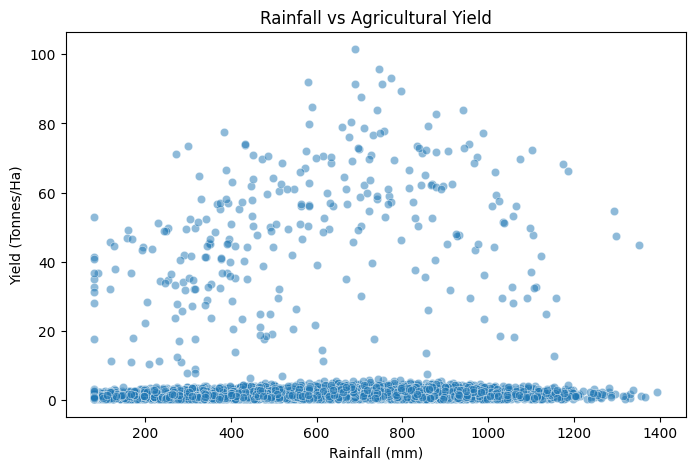

In [19]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=clean_df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    alpha=0.5
)

plt.title("Rainfall vs Agricultural Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

In [20]:
rainfall_yield_corr = clean_df["Rainfall_mm"].corr(
    clean_df["Yield_Tonnes_Ha"]
)

print("Correlation between Rainfall and Yield:", rainfall_yield_corr)

Correlation between Rainfall and Yield: 0.030950993551650874


In [21]:
temperature_yield_corr = clean_df["Avg_Temperature_C"].corr(
    clean_df["Yield_Tonnes_Ha"]
)

print("Correlation between Temperature and Yield:", temperature_yield_corr)

Correlation between Temperature and Yield: 0.009996320546703593


In [22]:
soil_moisture_yield_corr = clean_df["Soil_Moisture_pct"].corr(
    clean_df["Yield_Tonnes_Ha"]
)

print("Correlation between Soil Moisture and Yield:", soil_moisture_yield_corr)

Correlation between Soil Moisture and Yield: 0.010999346063015853


In [23]:
humidity_yield_corr = clean_df["Humidity_pct"].corr(
    clean_df["Yield_Tonnes_Ha"]
)

print("Correlation between Humidity and Yield:", humidity_yield_corr)

Correlation between Humidity and Yield: 0.012297441843645498


In [24]:
water_efficiency_yield_corr = clean_df["Water_Efficiency_t_per_1000m3"].corr(
    clean_df["Yield_Tonnes_Ha"]
)

print("Correlation between Water Efficiency and Yield:", water_efficiency_yield_corr)

Correlation between Water Efficiency and Yield: 0.9125675009144065


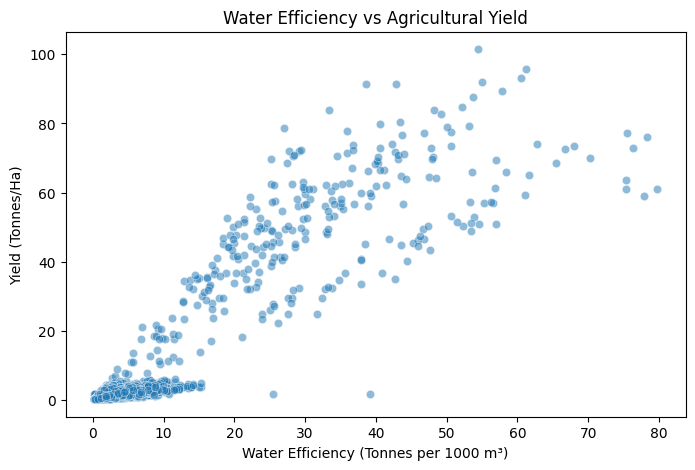

In [25]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=clean_df,
    x="Water_Efficiency_t_per_1000m3",
    y="Yield_Tonnes_Ha",
    alpha=0.5
)

plt.title("Water Efficiency vs Agricultural Yield")
plt.xlabel("Water Efficiency (Tonnes per 1000 m³)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

In [26]:
yield_profit_corr = clean_df["Yield_Tonnes_Ha"].corr(
    clean_df["Profit_INR"]
)

print("Correlation between Yield and Profit:", yield_profit_corr)

Correlation between Yield and Profit: 0.4884660989684235


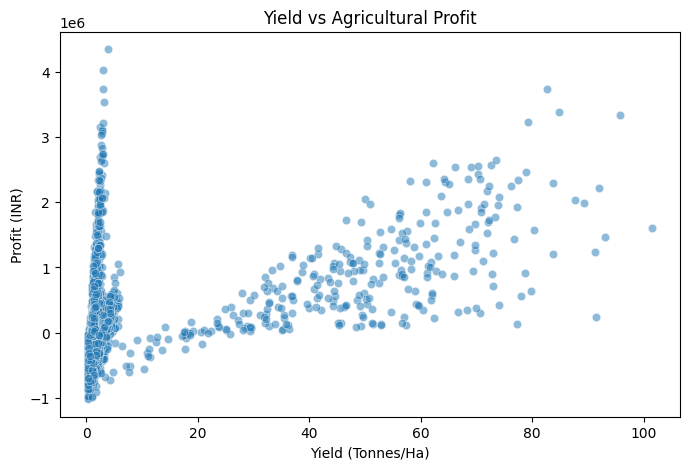

In [27]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=clean_df,
    x="Yield_Tonnes_Ha",
    y="Profit_INR",
    alpha=0.5
)

plt.title("Yield vs Agricultural Profit")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Profit (INR)")
plt.show()

In [28]:
crop_yield = clean_df.groupby("Crop")["Yield_Tonnes_Ha"].agg(
    ["count", "mean", "median"]
).sort_values("mean", ascending=False)

crop_yield

,count,mean,median
Crop,,,
Sugarcane,305,46.642361,47.880
Maize,551,2.710036,2.840
Rice,690,2.431304,2.440
Wheat,614,2.108013,2.215
Chilli,412,1.542767,1.565
Groundnut,424,1.322901,1.400
Cotton,508,1.229783,1.255
Pulses,496,0.921512,0.945


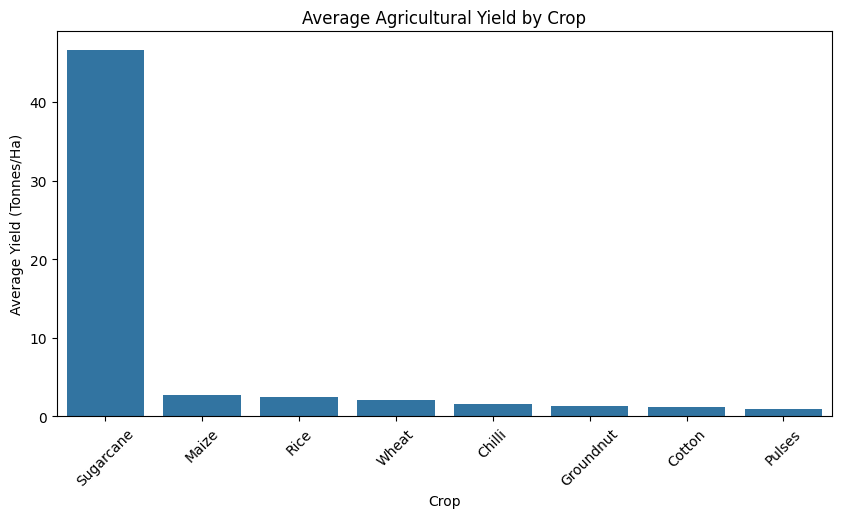

In [29]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=crop_yield.reset_index(),
    x="Crop",
    y="mean"
)

plt.title("Average Agricultural Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.show()

In [30]:
crop_profit = clean_df.groupby("Crop")["Profit_INR"].agg(
    ["count", "mean", "median"]
).sort_values("mean", ascending=False)

crop_profit

,count,mean,median
Crop,,,
Sugarcane,305,817187.986885,691166.0
Chilli,412,750878.342233,536375.0
Cotton,508,124546.915354,62092.5
Groundnut,424,44858.120283,36307.0
Pulses,496,-4238.052419,2575.5
Maize,551,-83978.326679,-42625.0
Rice,690,-102213.504348,-58286.0
Wheat,614,-123398.337134,-76269.0


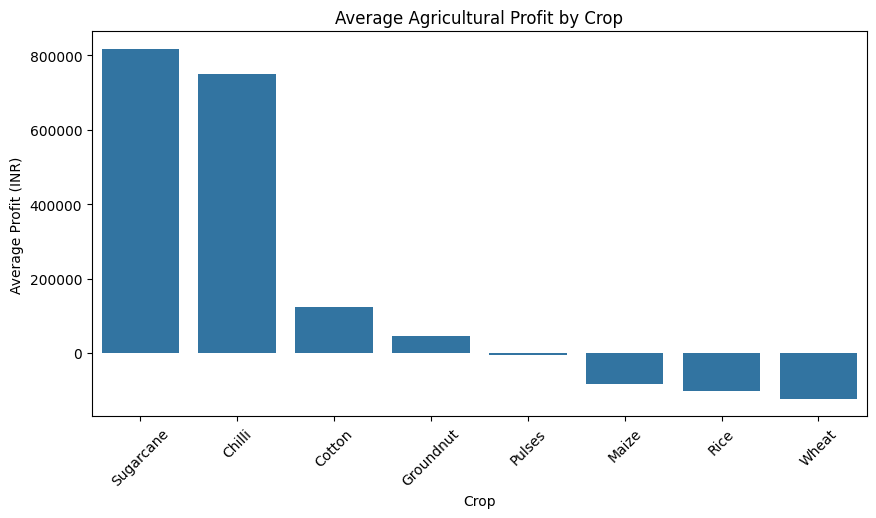

In [31]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=crop_profit.reset_index(),
    x="Crop",
    y="mean"
)

plt.title("Average Agricultural Profit by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45)
plt.show()

In [32]:
crop_season_yield = pd.pivot_table(
    clean_df,
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)

crop_season_yield

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.731459,1.465031,1.195312
Cotton,1.374512,1.198358,0.960217
Groundnut,1.484974,1.233164,1.037778
Maize,2.966410,2.603648,2.290952
Pulses,1.036063,0.875962,0.669677
Rice,2.698376,2.322847,1.900490
Sugarcane,53.459120,43.286124,38.423922
Wheat,2.253664,2.057468,1.748588


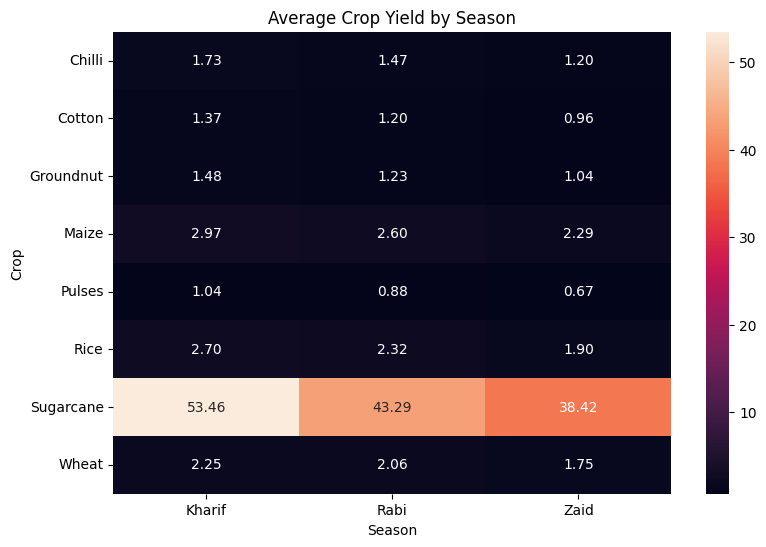

In [33]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt=".2f"
)

plt.title("Average Crop Yield by Season")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.show()

In [34]:
crop_season_profit = pd.pivot_table(
    clean_df,
    values="Profit_INR",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)

crop_season_profit

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,9.543804e+05,638572.496933,448659.093750
Cotton,2.169995e+05,107343.587065,-53925.336957
Groundnut,1.082654e+05,10416.542373,-68872.500000
Maize,-3.933267e+04,-89133.403433,-194049.166667
Pulses,4.333890e+04,-14309.136150,-139227.806452
Rice,-6.490340e+04,-98427.868613,-227239.343137
Sugarcane,1.000791e+06,731612.860465,583635.803922
Wheat,-1.058719e+05,-119954.565401,-193208.952941


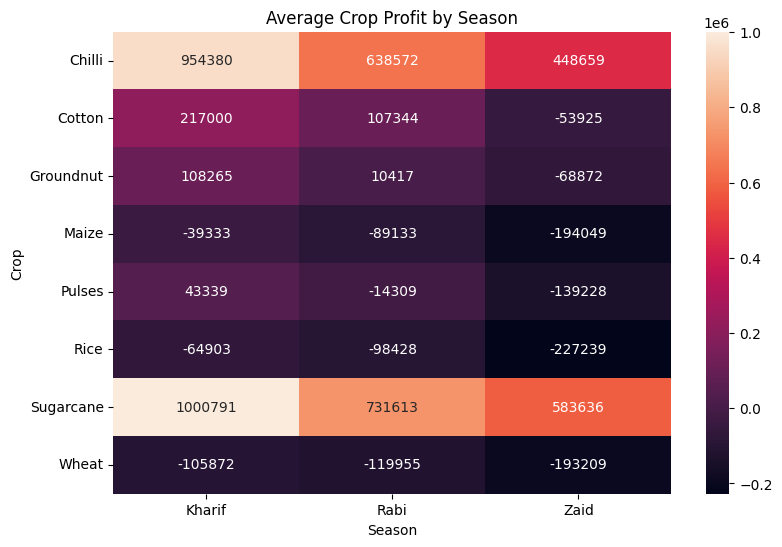

In [35]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    crop_season_profit,
    annot=True,
    fmt=".0f"
)

plt.title("Average Crop Profit by Season")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.show()

In [36]:
state_profit = clean_df.groupby("State")["Profit_INR"].agg(
    ["count", "mean", "median"]
).sort_values("mean", ascending=False)

state_profit

,count,mean,median
State,,,
Punjab,484,136025.636364,12463.5
Maharashtra,512,135428.855469,-840.5
Karnataka,489,119422.335378,15127.0
Tamil Nadu,485,117744.748454,-1569.0
Gujarat,488,117568.235656,3514.5
Telangana,516,108829.616279,16329.0
Madhya Pradesh,497,86840.756539,-3746.0
Andhra Pradesh,529,73453.527410,-3862.0


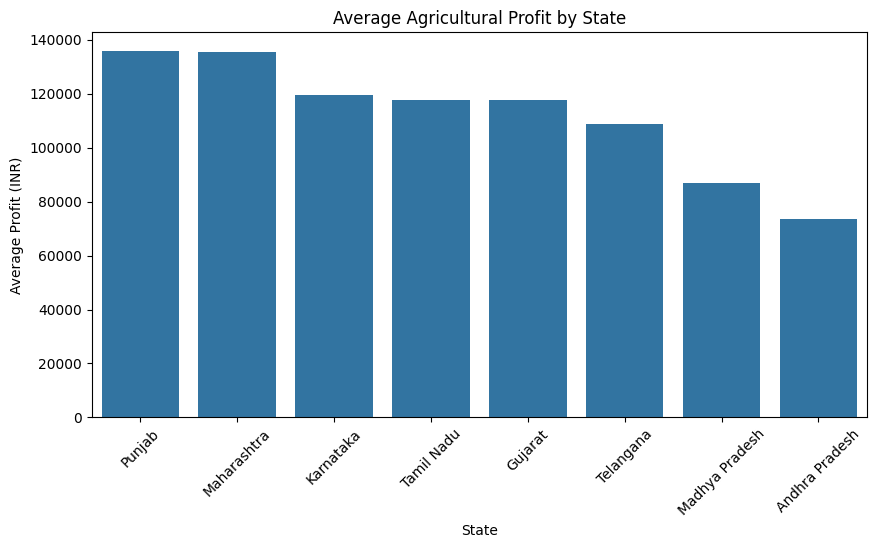

In [37]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=state_profit.reset_index(),
    x="State",
    y="mean"
)

plt.title("Average Agricultural Profit by State")
plt.xlabel("State")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45)
plt.show()

In [38]:
state_yield = clean_df.groupby("State")["Yield_Tonnes_Ha"].agg(
    ["count", "mean", "median"]
).sort_values("mean", ascending=False)

state_yield

,count,mean,median
State,,,
Punjab,484,6.121116,1.740
Karnataka,489,5.685481,1.750
Gujarat,488,5.659016,1.730
Telangana,516,5.044477,1.830
Maharashtra,512,5.017480,1.765
Madhya Pradesh,497,4.989940,1.690
Tamil Nadu,485,4.875175,1.740
Andhra Pradesh,529,4.628771,1.670


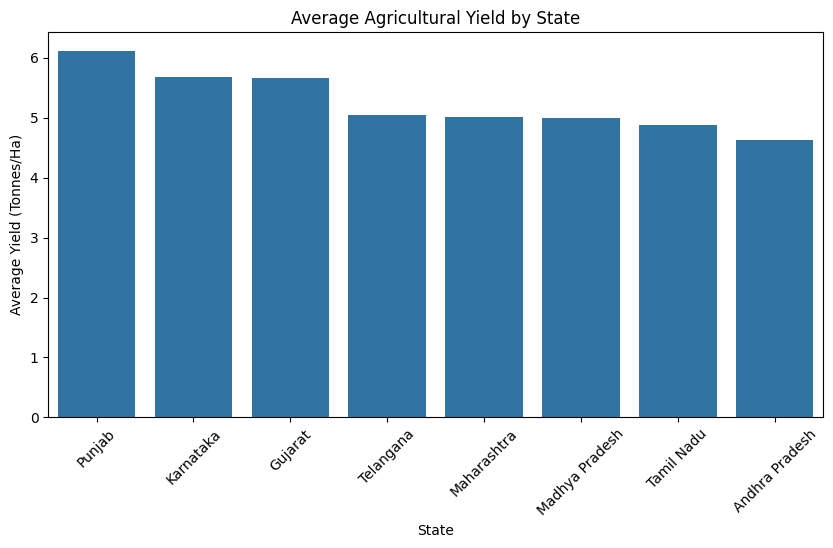

In [39]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=state_yield.reset_index(),
    x="State",
    y="mean"
)

plt.title("Average Agricultural Yield by State")
plt.xlabel("State")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.show()

In [40]:
from scipy.stats import f_oneway

kharif_yield = clean_df[clean_df["Season"] == "Kharif"]["Yield_Tonnes_Ha"]
rabi_yield = clean_df[clean_df["Season"] == "Rabi"]["Yield_Tonnes_Ha"]
zaid_yield = clean_df[clean_df["Season"] == "Zaid"]["Yield_Tonnes_Ha"]

f_stat, p_value = f_oneway(
    kharif_yield,
    rabi_yield,
    zaid_yield
)

print("ANOVA F-statistic:", f_stat)
print("ANOVA p-value:", p_value)

ANOVA F-statistic: 1.5438804542488311
ANOVA p-value: 0.21367813841792296


In [41]:
correlation_columns = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Soil_Moisture_pct",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Yield_Tonnes_Ha",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3"
]

correlation_matrix = clean_df[correlation_columns].corr()

correlation_matrix

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Fertilizer_kg_ha,Pesticide_Litre_ha,Yield_Tonnes_Ha,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3
Rainfall_mm,1.000000,0.198492,0.521069,0.508941,0.024602,0.004058,0.030951,0.107648,0.002240,0.058102
Avg_Temperature_C,0.198492,1.000000,0.138136,0.084001,0.015861,0.006657,0.009996,0.009043,0.022995,0.006534
Humidity_pct,0.521069,0.138136,1.000000,0.446470,0.024623,-0.004028,0.012297,0.063775,-0.002086,0.026169
Soil_Moisture_pct,0.508941,0.084001,0.446470,1.000000,0.008782,-0.023159,0.010999,0.091281,0.003183,0.027776
Fertilizer_kg_ha,0.024602,0.015861,0.024623,0.008782,1.000000,-0.001178,0.000018,-0.073542,0.000895,0.005077
Pesticide_Litre_ha,0.004058,0.006657,-0.004028,-0.023159,-0.001178,1.000000,-0.007779,-0.025705,0.002177,-0.006330
Yield_Tonnes_Ha,0.030951,0.009996,0.012297,0.010999,0.000018,-0.007779,1.000000,0.488466,0.386294,0.912568
Profit_INR,0.107648,0.009043,0.063775,0.091281,-0.073542,-0.025705,0.488466,1.000000,0.190278,0.489487
Water_Used_m3,0.002240,0.022995,-0.002086,0.003183,0.000895,0.002177,0.386294,0.190278,1.000000,0.217081
Water_Efficiency_t_per_1000m3,0.058102,0.006534,0.026169,0.027776,0.005077,-0.006330,0.912568,0.489487,0.217081,1.000000


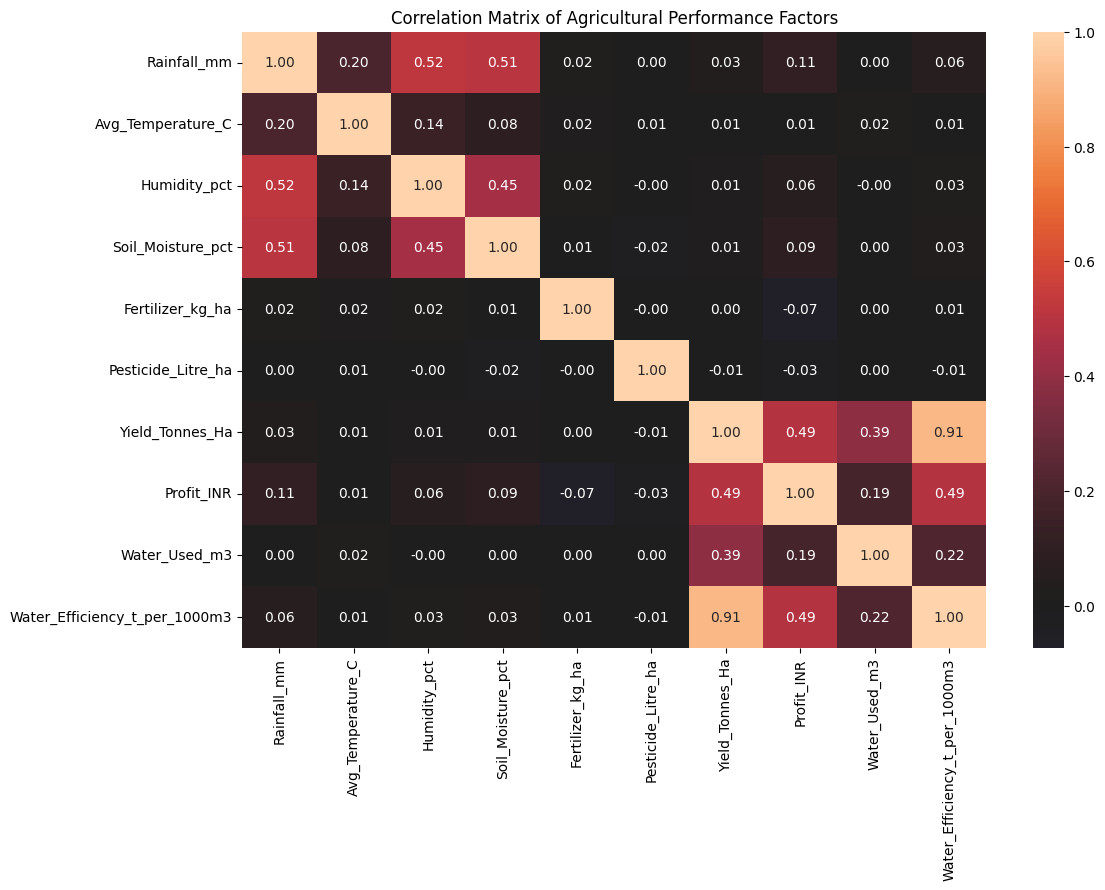

In [42]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    center=0
)

plt.title("Correlation Matrix of Agricultural Performance Factors")
plt.show()

In [43]:
Q1 = clean_df["Yield_Tonnes_Ha"].quantile(0.25)
Q3 = clean_df["Yield_Tonnes_Ha"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

yield_outliers = clean_df[
    (clean_df["Yield_Tonnes_Ha"] < lower_bound) |
    (clean_df["Yield_Tonnes_Ha"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Yield Outliers:", len(yield_outliers))

Q1: 1.05
Q3: 2.83
IQR: 1.78
Lower Bound: -1.6199999999999999
Upper Bound: 5.5
Number of Yield Outliers: 302


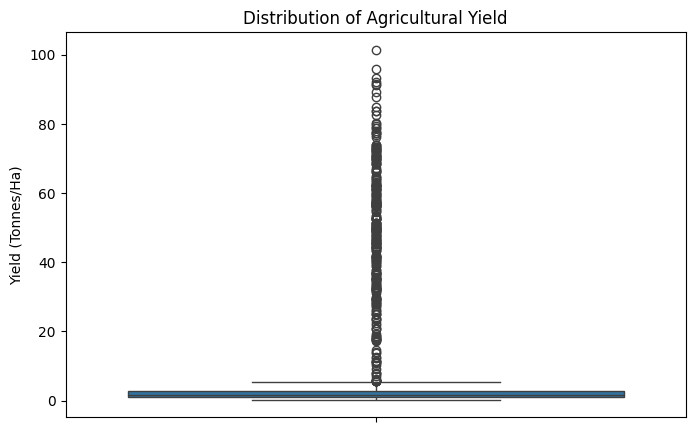

In [44]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    y=clean_df["Yield_Tonnes_Ha"]
)

plt.title("Distribution of Agricultural Yield")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

In [45]:
season_profitability = clean_df.groupby("Season")["Profit_INR"].apply(
    lambda x: (x > 0).mean() * 100
).sort_values(ascending=False)

print("Percentage of Profitable Farms by Season:")
print(season_profitability)

Percentage of Profitable Farms by Season:
Season
Kharif    57.785273
Rabi      48.862938
Zaid      35.521886
Name: Profit_INR, dtype: float64
